(torque4turbine)=
# Torque 2024 - 4 turbine cases

These cases place 4 turbines in a line with a spacing of 5 rotor diameters, and the turbine
diameters are 240 meters.
The layout is:
- x: [0.0, 1200.0, 2400.0, 3600.0]
- y: [0.0, 0.0, 0.0, 0.0]

The wind speed is 9.8 m/s and the wind direction is 270 degrees.

The following analytical wake models are included in FLORIS, FOXES, and PyWake.

**Velocity Models**
| Wake Model                        | FLORIS | FOXES | PyWake |
| --------------------------------- | ------ | ----- | ------ |
| **Jensen 1983**                   | •      | •     | •      |
| Larson 2009                       |        |       | •      |
| **Bastankhah / Porte Agel 2014**  |        | •     | •      |
| **Bastankhah / Porte Agel 2016**  | •      | •     |        |
| Niayifar / Porté-Agel 2016        |        |       | •      |
| IEA Task37 Bastankhah 2018        |        |       | •      |
| Carbajo Fuertes / Markfort / Porté-Agel 2018  |        |       | •      |
| Blondel / Cathelain 2020          |        |       | •      |
| Zong / Porté-Agel 2020            |        |       | •      |
| Cumulative Curl 2022              | •      |       |        |
| **TurbOPark (Nygaard 2022)**      | •*     | •     | •      |
| Empirical Gauss 2023              | •      |       |        |

**Deflection Models**
| Wake Model                        | FLORIS | FOXES | PyWake |
| --------------------------------- | ------ | ----- | ------ |
| **Jímenez 2010**                  | •      |       | •      |
| **Bastankhah / Porté-Agel 2016**  | •      | •     |        |
| Larsen et al 2020                 |        |       | •      |
| Empirical Gauss 2023              | •      |       |        |

In [1]:
# stdlib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# wcomp
from wcomp import WCompFloris, WCompPyWake, WCompFoxes
from wcomp.plotting import plot_plane

# plot settings
PROFILE_LINEWIDTH = 1.0
ERROR_LINEWIDTH = 1.5

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
# plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE)
plt.rc('legend', fontsize=MEDIUM_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)

# Constants for all cases. Copy to a particular code block to change, as needed.
CASE_DIR = Path('cases_torque2024/four_turbine')
this_case = CASE_DIR / Path('jensen/wind_energy_system.yaml')
floris_case = WCompFloris(this_case)
ROTOR_D = floris_case.rotor_diameter
XMIN = -1 * ROTOR_D
XMAX = (20+15) * ROTOR_D
YMIN = -2 * ROTOR_D
YMAX =  2 * ROTOR_D

SAVE_FIGS = False
SAVE_PATH = Path('figures')
if SAVE_FIGS:
    SAVE_PATH.mkdir(exist_ok=True)

/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(


## Case Layout

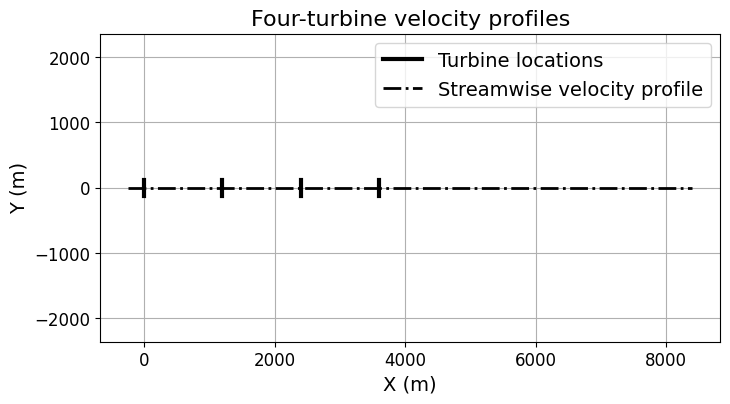

In [2]:
y_turbine = np.array([-ROTOR_D/2, ROTOR_D/2])
x_streamwise = np.array([XMIN, XMAX])
y_streamwise = np.array([0.0, 0.0])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([0, 0], y_turbine, color="black", linestyle='-', linewidth=3)
ax.plot([5*ROTOR_D, 5*ROTOR_D], y_turbine, color="black", linestyle='-', linewidth=3)
ax.plot([10*ROTOR_D, 10*ROTOR_D], y_turbine, color="black", linestyle='-', linewidth=3)
ax.plot([15*ROTOR_D, 15*ROTOR_D], y_turbine, color="black", linestyle='-', linewidth=3, label="Turbine locations")
ax.plot(x_streamwise, y_streamwise, '-.', color='black', linewidth=2, label="Streamwise velocity profile")
ax.set_title("Four-turbine velocity profiles")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_ylim([-1000, 1000])
ax.axis('equal')
ax.grid()
ax.legend()

if SAVE_FIGS: fig.savefig(SAVE_PATH / Path('4t config.png'))

## Velocity models

### Jensen

This is the Jensen model as described in the paper:
A note on wind generator interaction (1983)
https://backend.orbit.dtu.dk/ws/portalfiles/portal/55857682/ris_m_2411.pdf

There, the wake width is given as 0.1 on pages 6 and 8.
PyWake has 0.1 as default
FLORIS has 0.05 as default, but it is changed to 0.1 here.
FOXES has a set of predefined Jensen wake models available, but you are expected to create your own, as needed. That is done here with k=0.1.

Implemented in: FLORIS, FOXES, PyWake

Turbine 0, T0: xy=(0.00, 0.00), windio_turbine
Turbine 1, T1: xy=(1200.00, 0.00), windio_turbine
Turbine 2, T2: xy=(2400.00, 0.00), windio_turbine
Turbine 3, T3: xy=(3600.00, 0.00), windio_turbine
Selecting 'DefaultEngine(n_procs=14, chunk_size_states=None, chunk_size_points=None)'
DefaultEngine: Selecting engine 'single'
SingleChunkEngine: Calculating 1 states for 4 turbines
SingleChunkEngine: Starting calculation using a single worker.
SingleChunkEngine: Completed all 1 chunks

DefaultEngine: Selecting engine 'single'
SingleChunkEngine: Calculating data at 100 points for 1 states
SingleChunkEngine: Starting calculation using a single worker.
SingleChunkEngine: Completed all 1 chunks

Error norm:
2.6329332064277438
3.5667386439657554


/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(


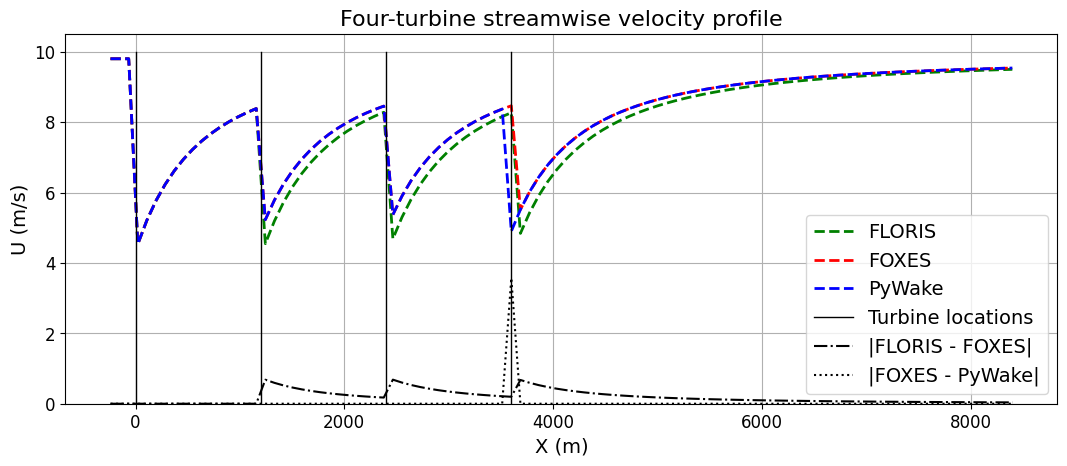

In [ ]:
this_case = CASE_DIR / Path('jensen/wind_energy_system.yaml')
floris_1turbine = WCompFloris(this_case)
foxes_1turbine = WCompFoxes(this_case)
pywake_1turbine = WCompPyWake(this_case)

### Streamwise profile plot

fig, ax = plt.subplots(figsize=(12.8, 4.8))
ax.set_title("Four-turbine streamwise velocity profile")
ax.set_xlabel("X (m)")
ax.set_ylabel('U (m/s)')
ax.set_ybound(lower=0.0)
ax.grid()

# Create the simulation data and plot onto current mpl axis
floris_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
foxes_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
pywake_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)

# Add vertical lines at the locations of the cross-stream profiles
ax.plot([0, 0], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([5*ROTOR_D, 5*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([10*ROTOR_D, 10*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([15*ROTOR_D, 15*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH, label="Turbine locations")

# Extract the lines to calculate the errors and plot
lines = ax.lines
x1, y1 = lines[0].get_data()
x2, y2 = lines[1].get_data()
x3, y3 = lines[2].get_data()
e1 = np.abs(y1 - y2)
e2 = np.abs(y2 - y3)
emax = np.max([np.max(e1), np.max(e2)])
ax.plot(x1, e1, color="black", linestyle='-.', linewidth=ERROR_LINEWIDTH, label="|FLORIS - FOXES|")
ax.plot(x1, e2, color="black", linestyle=':', linewidth=ERROR_LINEWIDTH, label="|FOXES - PyWake|")

ax.legend()

if SAVE_FIGS: fig.savefig(SAVE_PATH / Path('jensen 4t.png'))
# print("Error norm:")
# print(np.linalg.norm(e1, ord=2))
# print(np.linalg.norm(e2, ord=2))

### Crosswise profile plots

# fig, ax = plt.subplots(3, 1)
# fig.suptitle("Cross section velocity profile")
# X_D = [1, 5, 10]
# for i, D_X in enumerate(X_D):
#     plt.axes(ax[i])
#     floris_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     foxes_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     pywake_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     ax[i].set_title(f"{D_X} D")
#     ax[i].set_ylabel("U (m/s)")
#     ax[i].set_ybound(lower=0.0, upper=12.0)
#     ax[i].grid()
#     if i < len(X_D) - 1:
#         ax[i].xaxis.set_ticklabels([])
#     else:
#         ax[i].set_xlabel("Y (m)")
#         ax[i].legend()

### Bastankhah / Porte Agel 2014

A new analytical model for wind-turbine wakes
https://www.sciencedirect.com/science/article/abs/pii/S0960148114000317

k*, the wake growth rate d-sigma/dx, is the only parameter

Implemented in: FOXES, PyWake

Turbine 0, T0: xy=(0.00, 0.00), windio_turbine
Turbine 1, T1: xy=(1200.00, 0.00), windio_turbine
Turbine 2, T2: xy=(2400.00, 0.00), windio_turbine
Turbine 3, T3: xy=(3600.00, 0.00), windio_turbine
DefaultEngine: Selecting engine 'single'
SingleChunkEngine: Calculating 1 states for 4 turbines
SingleChunkEngine: Starting calculation using a single worker.
SingleChunkEngine: Completed all 1 chunks

DefaultEngine: Selecting engine 'single'
SingleChunkEngine: Calculating data at 100 points for 1 states
SingleChunkEngine: Starting calculation using a single worker.
SingleChunkEngine: Completed all 1 chunks



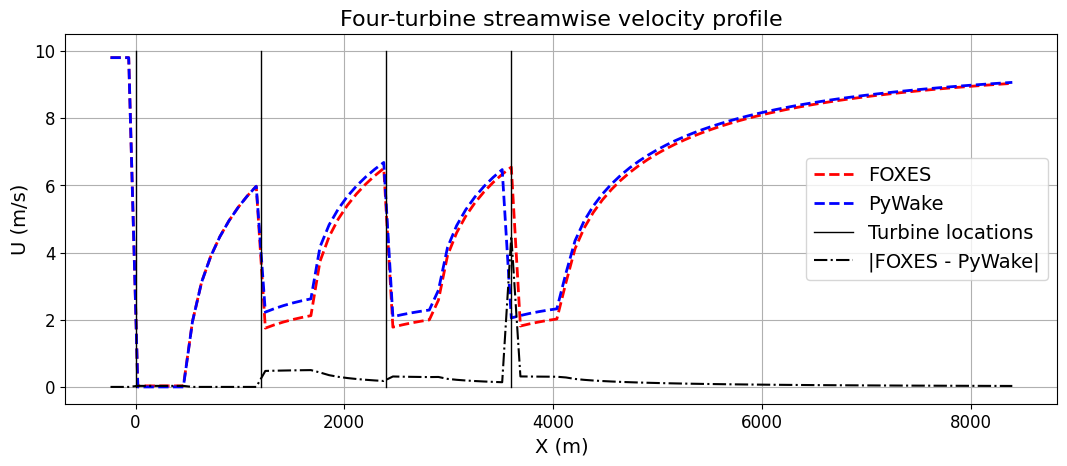

In [8]:
this_case = CASE_DIR / Path('bastankhah2014/wind_energy_system.yaml')
# floris_1turbine = WCompFloris(this_case)  # Not implemented
foxes_1turbine = WCompFoxes(this_case)
pywake_1turbine = WCompPyWake(this_case)

### Streamwise profile plot

fig, ax = plt.subplots(figsize=(12.8, 4.8))
ax.set_title("Four-turbine streamwise velocity profile")
ax.set_xlabel("X (m)")
ax.set_ylabel('U (m/s)')
ax.set_ybound(lower=0.0)
ax.grid()

# Create the simulation data and plot onto current mpl axis
# floris_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
foxes_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
pywake_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)

# Add vertical lines at the locations of the cross-stream profiles
ax.plot([0, 0], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([5*ROTOR_D, 5*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([10*ROTOR_D, 10*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([15*ROTOR_D, 15*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH, label="Turbine locations")

# Extract the lines to calculate the errors and plot
lines = ax.lines
x1, y1 = lines[0].get_data()
x2, y2 = lines[1].get_data()
e1 = np.abs(y1 - y2)
emax = np.max([np.max(e1), np.max(e2)])
ax.plot(x1, e1, color="black", linestyle='-.', linewidth=ERROR_LINEWIDTH, label="|FOXES - PyWake|")

ax.legend()

if SAVE_FIGS: fig.savefig(SAVE_PATH / Path('b2014 4t.png'))
# print("Error norm:")
# print(np.linalg.norm(e1, ord=2))

### Crosswise profile plots

# fig, ax = plt.subplots(3, 1)
# fig.suptitle("Cross section velocity profile")
# X_D = [1, 5, 10]
# for i, D_X in enumerate(X_D):
#     plt.axes(ax[i])
#     # floris_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     foxes_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     pywake_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     ax[i].set_title(f"{D_X} D")
#     ax[i].set_ylabel("U (m/s)")
#     ax[i].set_ybound(lower=0.0, upper=12.0)
#     ax[i].grid()
#     if i < len(X_D) - 1:
#         ax[i].xaxis.set_ticklabels([])
#     else:
#         ax[i].set_xlabel("Y (m)")
#         ax[i].legend()

### Bastankhah / Porte Agel 2016

Experimental and theoretical study of wind turbine wakes in yawed conditions
https://www.cambridge.org/core/journals/journal-of-fluid-mechanics/article/experimental-and-theoretical-study-of-wind-turbine-wakes-in-yawed-conditions/400859134E38F340C8811FD7AAD0CE05

ky, kz are wake growth rates in the y and z directions
Eq 6.16 has parameters alpha and beta and below says that they are 0.58 and 0.077.
Equations 7.1 - 7.4 summarize the model but use parameters alpha_star and beta_star, which are 2.32 and 0.154.
These are related to alpha and beta by:
- alpha_star = 4 * alpha = 4 * 0.58 = 2.32
- beta_star = 2 * beta = 2 * 0.077 = 0.154

In the near wake, the distribution away from the wake centerline is given by 6.13.

Implemented in: FOXES, PyWake

NOTE: k is set to 0.022 as mentioned in the last paragraph of section 4.

NOTE: FLORIS has ky and kz parameters, but FOXES uses the same, k, for both.
This simplification is mentioned in the paper in section 7 Model Predictions.
For simplicity, FLORIS uses k for both ky and kz.

NOTE: FLORIS sets ky and kz in the deflection model based on Eq 15 from Niayifar / Porte Agel 2016 https://www.mdpi.com/1996-1073/9/9/741
ky = kz = ka * I + kb
ka = 0.3837
kb = 0.003678
Where as Bastankhah / Porte Agel 2016 sets ky and kz directly as in the velocity model.

Turbine 0, T0: xy=(0.00, 0.00), windio_turbine
Turbine 1, T1: xy=(1200.00, 0.00), windio_turbine
Turbine 2, T2: xy=(2400.00, 0.00), windio_turbine
Turbine 3, T3: xy=(3600.00, 0.00), windio_turbine
DefaultEngine: Selecting engine 'single'
SingleChunkEngine: Calculating 1 states for 4 turbines
SingleChunkEngine: Starting calculation using a single worker.
SingleChunkEngine: Completed all 1 chunks

DefaultEngine: Selecting engine 'single'
SingleChunkEngine: Calculating data at 100 points for 1 states
SingleChunkEngine: Starting calculation using a single worker.
SingleChunkEngine: Completed all 1 chunks



/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(
/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(


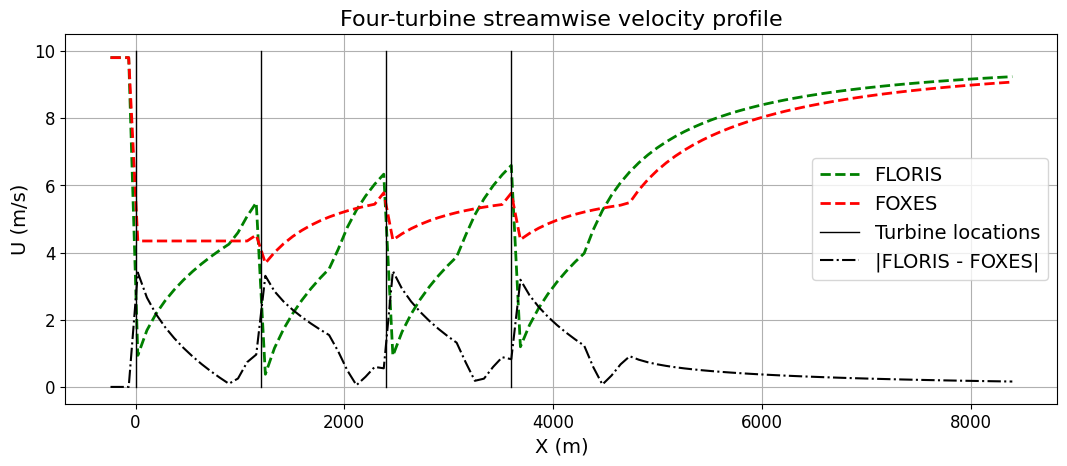

In [9]:
this_case = CASE_DIR / Path('bastankhah2016/wind_energy_system.yaml')
floris_1turbine = WCompFloris(this_case)
foxes_1turbine = WCompFoxes(this_case)
# pywake_1turbine = WCompPyWake(this_case)

### Streamwise profile plot

fig, ax = plt.subplots(figsize=(12.8, 4.8))
ax.set_title("Four-turbine streamwise velocity profile")
ax.set_xlabel("X (m)")
ax.set_ylabel('U (m/s)')
ax.set_ybound(lower=0.0)
ax.grid()

# Create the simulation data and plot onto current mpl axis
floris_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
foxes_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
# pywake_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)

# Add vertical lines at the locations of the cross-stream profiles
ax.plot([0, 0], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([5*ROTOR_D, 5*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([10*ROTOR_D, 10*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([15*ROTOR_D, 15*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH, label="Turbine locations")

# Extract the lines to calculate the errors and plot
lines = ax.lines
x1, y1 = lines[0].get_data()
x2, y2 = lines[1].get_data()
e1 = np.abs(y1 - y2)
emax = np.max([np.max(e1), np.max(e2)])
ax.plot(x1, e1, color="black", linestyle='-.', linewidth=ERROR_LINEWIDTH, label="|FLORIS - FOXES|")

ax.legend()

if SAVE_FIGS: fig.savefig(SAVE_PATH / Path('b2016 4t.png'))
# print("Error norm:")
# print(np.linalg.norm(e1, ord=2))

### Crosswise profile plots

# fig, ax = plt.subplots(3, 1)
# fig.suptitle("Cross section velocity profile")
# X_D = [1, 5, 10]
# for i, D_X in enumerate(X_D):
#     plt.axes(ax[i])
#     floris_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     foxes_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     # pywake_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     ax[i].set_title(f"{D_X} D")
#     ax[i].set_ylabel("U (m/s)")
#     ax[i].set_ybound(lower=0.0, upper=12.0)
#     ax[i].grid()
#     if i < len(X_D) - 1:
#         ax[i].xaxis.set_ticklabels([])
#     else:
#         ax[i].set_xlabel("Y (m)")
#         ax[i].legend()

### TurbOPark

Modelling cluster wakes and wind farm blockage
https://iopscience.iop.org/article/10.1088/1742-6596/1618/6/062072

The only parameter is A with value = 0.04

Implemented in: FLORIS, FOXES, PyWake

Turbine 0, T0: xy=(0.00, 0.00), windio_turbine
Turbine 1, T1: xy=(1200.00, 0.00), windio_turbine
Turbine 2, T2: xy=(2400.00, 0.00), windio_turbine
Turbine 3, T3: xy=(3600.00, 0.00), windio_turbine
DefaultEngine: Selecting engine 'single'
SingleChunkEngine: Calculating 1 states for 4 turbines
SingleChunkEngine: Starting calculation using a single worker.
SingleChunkEngine: Completed all 1 chunks

DefaultEngine: Selecting engine 'single'
SingleChunkEngine: Calculating data at 100 points for 1 states
SingleChunkEngine: Starting calculation using a single worker.
SingleChunkEngine: Completed all 1 chunks



/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(
/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(


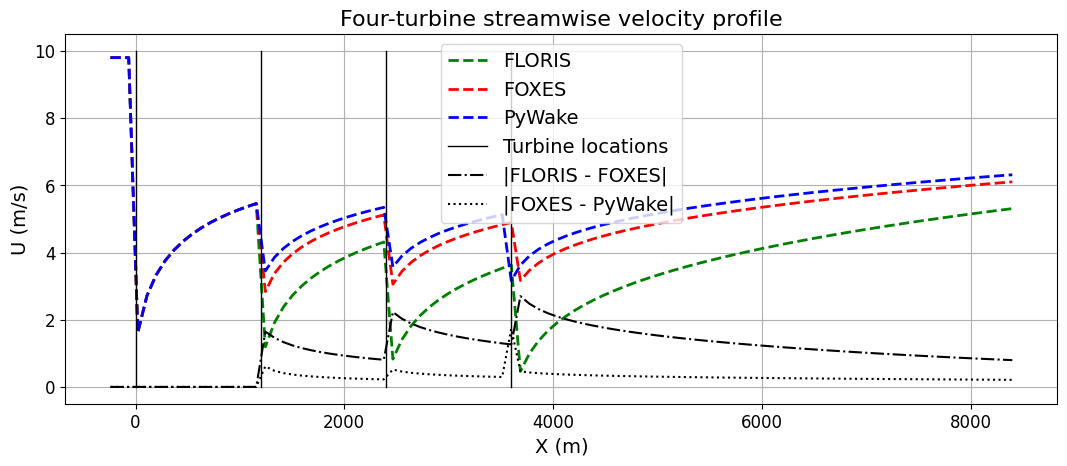

In [11]:
this_case = CASE_DIR / Path('turbopark/wind_energy_system.yaml')
floris_1turbine = WCompFloris(this_case)
foxes_1turbine = WCompFoxes(this_case)
pywake_1turbine = WCompPyWake(this_case)

### Streamwise profile plot

fig, ax = plt.subplots(figsize=(12.8, 4.8))
ax.set_title("Four-turbine streamwise velocity profile")
ax.set_xlabel("X (m)")
ax.set_ylabel('U (m/s)')
ax.set_ybound(lower=0.0)
ax.grid()

# Create the simulation data and plot onto current mpl axis
floris_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
foxes_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
pywake_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)

# Add vertical lines at the locations of the cross-stream profiles
ax.plot([0, 0], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([5*ROTOR_D, 5*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([10*ROTOR_D, 10*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([15*ROTOR_D, 15*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH, label="Turbine locations")

# Extract the lines to calculate the errors and plot
lines = ax.lines
x1, y1 = lines[0].get_data()
x2, y2 = lines[1].get_data()
x3, y3 = lines[2].get_data()
e1 = np.abs(y1 - y2)
e2 = np.abs(y2 - y3)
emax = np.max([np.max(e1), np.max(e2)])
ax.plot(x1, e1, color="black", linestyle='-.', linewidth=ERROR_LINEWIDTH, label="|FLORIS - FOXES|")
ax.plot(x1, e2, color="black", linestyle=':', linewidth=ERROR_LINEWIDTH, label="|FOXES - PyWake|")

ax.legend()

if SAVE_FIGS: fig.savefig(SAVE_PATH / Path('turbopark 4t.png'))
# print("Error norm:")
# print(np.linalg.norm(e1, ord=2))
# print(np.linalg.norm(e2, ord=2))

### Crosswise profile plots

# fig, ax = plt.subplots(3, 1)
# fig.suptitle("Cross section velocity profile")
# fig.tight_layout()

# X_D = [1, 5, 10]
# for i, D_X in enumerate(X_D):
#     plt.axes(ax[i])

#     # Create the simulation data and plot onto current mpl axis
#     floris_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     foxes_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     pywake_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)

#     ax[i].set_title(f"{D_X} D")
#     ax[i].set_ylabel("U (m/s)")
#     ax[i].set_ybound(lower=0.0, upper=12.0)
#     ax[i].grid()
#     if i < len(X_D) - 1:
#         ax[i].xaxis.set_ticklabels([])
#     else:
#         ax[i].set_xlabel("Y (m)")
#         ax[i].legend()
# if SAVE_FIGS: fig.savefig(SAVE_PATH / Path('turbopark 4t y.png'))

## Wake deflection models

Here we yaw the turbines 10 degrees to activate the wake deflection models.

### Jimenez

Application of a LES technique to characterize the wake deflection of a wind turbine in yaw
https://onlinelibrary.wiley.com/doi/10.1002/we.380

Using the Jensen velocity deficit model, we compare the Jimenez deflection models.

beta is the only parameter, and the paper suggest values between 0.9 and 0.125. We use 0.1.

NOTE: The FLORIS implementation does not correlate to the paper, and there are additional parameters.
ad, bd are default to 0 so that was left.
I've set kd to beta.

Implemented in: FLORIS and PyWake

/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(
/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(
/Users/raf/miniforge3/envs/wcomp/lib/python3.14/site-packages/floris/core/flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(


Error norm:
4.274196853600336


ValueError: dimensions () must have the same length as the number of data dimensions, ndim=1

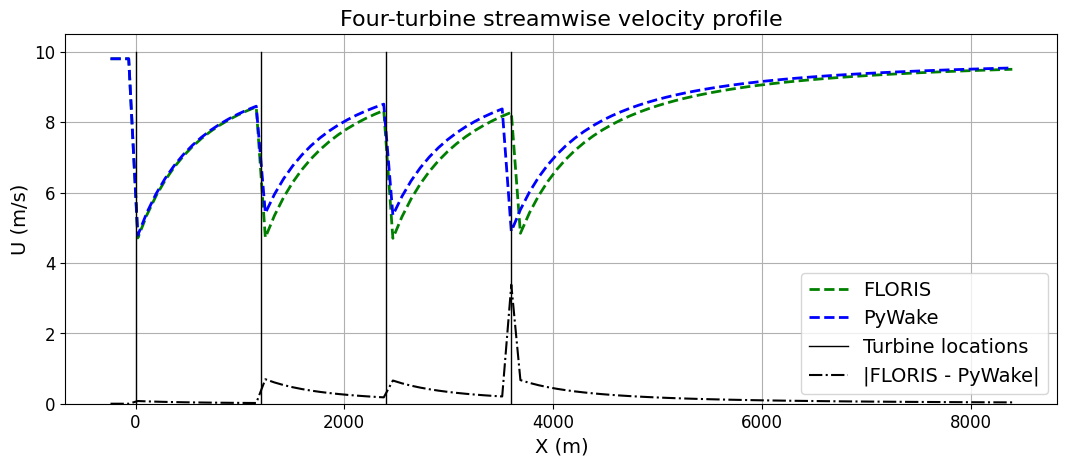

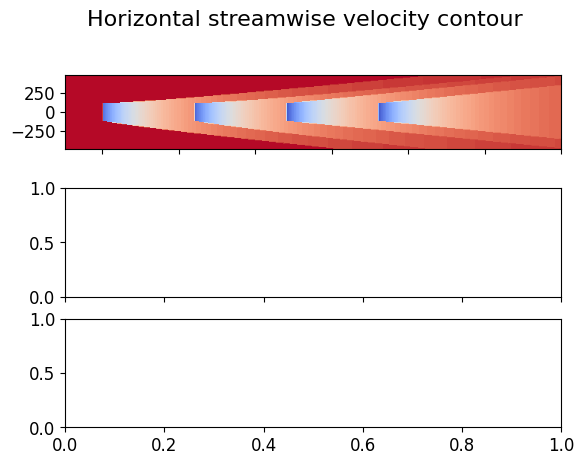

In [7]:
this_case = CASE_DIR / Path('jimenez/wind_energy_system.yaml')
floris_1turbine = WCompFloris(this_case)
# foxes_1turbine = WCompFoxes(this_case)
pywake_1turbine = WCompPyWake(this_case)

fig, ax = plt.subplots(figsize=(12.8, 4.8))
floris_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
# foxes_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
pywake_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
ax.plot([0, 0], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([5*ROTOR_D, 5*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([10*ROTOR_D, 10*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH)
ax.plot([15*ROTOR_D, 15*ROTOR_D], [0, 10], color="black", linestyle='-', linewidth=PROFILE_LINEWIDTH, label="Turbine locations")
lines = ax.lines
x1, y1 = lines[0].get_data()
x2, y2 = lines[1].get_data()
e1 = np.abs(y1 - y2)
emax = np.max([np.max(e1), np.max(e2)])
ax.plot(x1, e1, color="black", linestyle='-.', linewidth=ERROR_LINEWIDTH, label="|FLORIS - PyWake|")
ax.set_title("Four-turbine streamwise velocity profile")
ax.set_xlabel("X (m)")
ax.set_ylabel('U (m/s)')
ax.set_ybound(lower=0.0)
ax.legend()
ax.grid()
if SAVE_FIGS: fig.savefig(SAVE_PATH / Path('jimenez 4t.png'))

print("Error norm:")
print(np.linalg.norm(e1, ord=2))


# fig, ax = plt.subplots(3, 1)
# fig.suptitle("Cross section velocity profile")
# X_D = [1, 5, 10]
# for i, D_X in enumerate(X_D):
#     plt.axes(ax[i])
#     floris_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     # foxes_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     pywake_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     ax[i].set_title(f"{D_X} D")
#     ax[i].set_ylabel("U (m/s)")
#     ax[i].set_ybound(lower=0.0, upper=12.0)
#     ax[i].grid()
#     if i < len(X_D) - 1:
#         ax[i].xaxis.set_ticklabels([])
#     else:
#         ax[i].set_xlabel("Y (m)")
#         ax[i].legend()


fig, ax = plt.subplots(3, 1)
fig.suptitle("Horizontal streamwise velocity contour")

plt.axes(ax[0])
ax[0].xaxis.set_ticklabels([])
floris_plane = floris_1turbine.horizontal_contour(wind_direction=270)

plt.axes(ax[1])
ax[1].xaxis.set_ticklabels([])
# foxes_plane = foxes_1turbine.horizontal_contour(wind_direction=270)

plt.axes(ax[2])
ax[1].xaxis.set_ticklabels([])
pywake_plane = pywake_1turbine.horizontal_contour(wind_direction=270)


fig, ax = plt.subplots(2, 1)
fig.suptitle("Diff: FLORIS as basis")

plt.axes(ax[0])
diff = floris_plane - pywake_plane
abs_diff = np.abs(diff.values)
min_speed = -1 * np.max(abs_diff)
max_speed = np.max(abs_diff)
plot_plane(
    diff,
    min_speed=min_speed,
    max_speed=max_speed,
    cmap='PuOr',
    clevels=100,
    color_bar=True,
    title="FLORIS - PyWake"
)

# plt.axes(ax[1])
# diff = floris_plane - foxes_plane
# abs_diff = np.abs(diff.values)
# min_speed = -1 * np.max(abs_diff)
# max_speed = np.max(abs_diff)
# plot_plane(
#     diff,
#     ax=ax[1],
#     min_speed=min_speed,
#     max_speed=max_speed,
#     cmap='PuOr',
#     clevels=100,
#     color_bar=True,
#     title="FLORIS - FOXES"
# )

### Bastankhah / Porte Agel 2016

Experimental and theoretical study of wind turbine wakes in yawed conditions
https://www.cambridge.org/core/journals/journal-of-fluid-mechanics/article/experimental-and-theoretical-study-of-wind-turbine-wakes-in-yawed-conditions/400859134E38F340C8811FD7AAD0CE05

ky, kz are wake growth rates in the y and z directions
Eq 6.16 has parameters alpha and beta and below says that they are 0.58 and 0.077.
Equations 7.1 - 7.4 summarize the model but use parameters alpha_star and beta_star, which are 2.32 and 0.154.
These are related to alpha and beta by:
- alpha_star = 4 * alpha = 4 * 0.58 = 2.32
- beta_star = 2 * beta = 2 * 0.077 = 0.154

In the near wake, the distribution away from the wake centerline is given by 6.13.

Implemented in: FLORIS, FOXES
PyWake implements the velocity model, but not the deflection model.

NOTE: k is set to 0.022 as mentioned in the last paragraph of section 4.

NOTE: FLORIS has ky and kz parameters, but FOXES uses the same, k, for both.
This simplification is mentioned in the paper in section 7 Model Predictions.
For simplicity, FLORIS uses k for both ky and kz.

NOTE: FLORIS sets ky and kz in the deflection model based on Eq 15 from Niayifar / Porte Agel 2016 https://www.mdpi.com/1996-1073/9/9/741
ky = kz = ka * I + kb
ka = 0.3837
kb = 0.003678
Where as Bastankhah / Porte Agel 2016 sets ky and kz directly as in the velocity model.


Turbine 0, T0: windio_turbine
Turbine 1, T1: windio_turbine
Turbine 2, T2: windio_turbine
Turbine 3, T3: windio_turbine
Error norm:
12.37551468901952


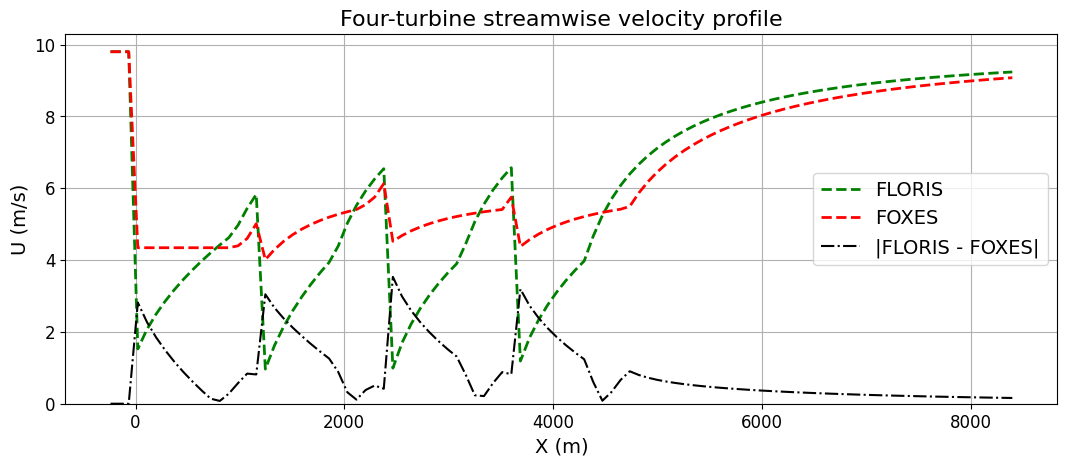

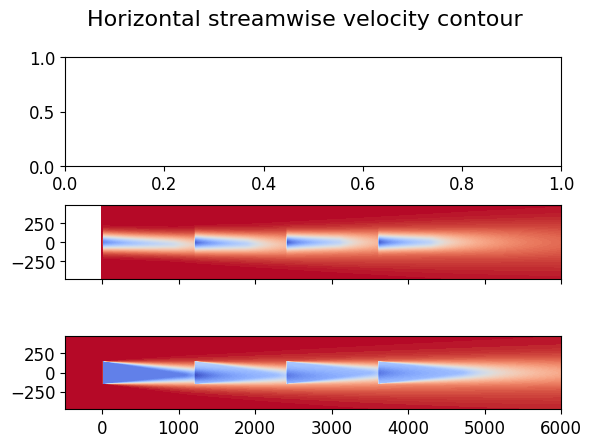

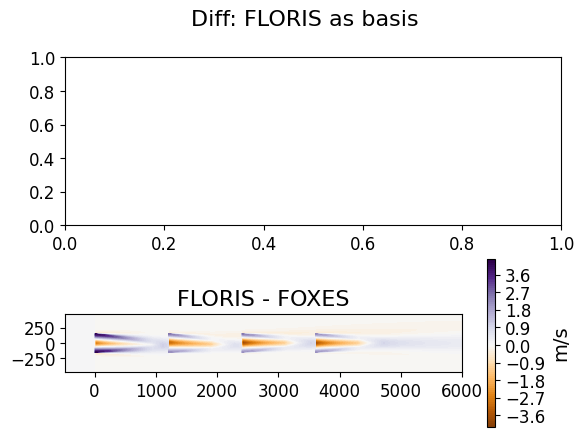

In [ ]:
this_case = CASE_DIR / Path('bastankhah2016_deflection/wind_energy_system.yaml')
floris_1turbine = WCompFloris(this_case)
foxes_1turbine = WCompFoxes(this_case)
# pywake_1turbine = WCompPyWake(this_case)

fig, ax = plt.subplots(figsize=(12.8, 4.8))
floris_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
foxes_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
# pywake_1turbine.streamwise_profile_plot(wind_direction=270, y_coordinate=0.0, xmin=XMIN, xmax=XMAX)
lines = ax.lines
x1, y1 = lines[0].get_data()
x2, y2 = lines[1].get_data()
e1 = np.abs(y1 - y2)
emax = np.max([np.max(e1), np.max(e2)])
ax.plot(x1, e1, color="black", linestyle='-.', linewidth=ERROR_LINEWIDTH, label="|FLORIS - FOXES|")
ax.set_title("Four-turbine streamwise velocity profile")
ax.set_xlabel("X (m)")
ax.set_ylabel('U (m/s)')
ax.set_ybound(lower=0.0)
ax.legend()
ax.grid()
if SAVE_FIGS: fig.savefig(SAVE_PATH / Path('b2016 deflection 4t.png'))

print("Error norm:")
print(np.linalg.norm(e1, ord=2))


# fig, ax = plt.subplots(3, 1)
# fig.suptitle("Cross section velocity profile")
# X_D = [1, 5, 10]
# for i, D_X in enumerate(X_D):
#     plt.axes(ax[i])
#     floris_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     foxes_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     # pywake_1turbine.xsection_profile_plot(wind_direction=270, x_coordinate=D_X * ROTOR_D, ymin=YMIN, ymax=YMAX)
#     ax[i].set_title(f"{D_X} D")
#     ax[i].set_ylabel("U (m/s)")
#     ax[i].set_ybound(lower=0.0, upper=12.0)
#     ax[i].grid()
#     if i < len(X_D) - 1:
#         ax[i].xaxis.set_ticklabels([])
#     else:
#         ax[i].set_xlabel("Y (m)")
#         ax[i].legend()


fig, ax = plt.subplots(3, 1)
fig.suptitle("Horizontal streamwise velocity contour")

plt.axes(ax[0])
# ax[0].xaxis.set_ticklabels([])
# pywake_plane = pywake_1turbine.horizontal_contour(wind_direction=270)

plt.axes(ax[1])
ax[1].xaxis.set_ticklabels([])
floris_plane = floris_1turbine.horizontal_contour(wind_direction=270)

plt.axes(ax[2])
ax[1].xaxis.set_ticklabels([])
foxes_plane = foxes_1turbine.horizontal_contour(wind_direction=270)


fig, ax = plt.subplots(2, 1)
fig.suptitle("Diff: FLORIS as basis")

plt.axes(ax[0])
# diff = floris_plane - pywake_plane
# abs_diff = np.abs(diff.values)
# min_speed = -1 * np.max(abs_diff)
# max_speed = np.max(abs_diff)
# plot_plane(
#     diff,
#     ax=ax[0],
#     min_speed=min_speed,
#     max_speed=max_speed,
#     cmap='PuOr',
#     clevels=100,
#     color_bar=True,
#     title="FLORIS - PyWake"
# )

plt.axes(ax[1])
diff = floris_plane - foxes_plane
abs_diff = np.abs(diff.values)
min_speed = -1 * np.max(abs_diff)
max_speed = np.max(abs_diff)
plot_plane(
    diff,
    min_speed=min_speed,
    max_speed=max_speed,
    cmap='PuOr',
    clevels=100,
    color_bar=True,
    title="FLORIS - FOXES"
)